#  ESP32 TinyML Model - Compatible with .TS Files
## Training PPG Data → Arduino Deployment

In [ ]:
# Setup
from google.colab import drive
drive.mount('/content/drive')

!pip install tensorflow numpy pandas scipy scikit-learn matplotlib -q

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import os

np.random.seed(42)
tf.random.set_seed(42)

print('✓ Libraries loaded')

Mounted at /content/drive
✓ Libraries loaded


In [ ]:
import numpy as np

def load_ts_file(filepath):
    """
    Load .ts file format that contains @ metadata headers.
    Skips headers and parses the numerical data after the @data tag.
    """
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            lines = f.readlines()

        # 1. Find where the actual data begins
        data_start_index = 0
        for i, line in enumerate(lines):
            if line.strip().lower() == '@data':
                data_start_index = i + 1
                break

        # 2. Extract just the data lines
        data_lines = lines[data_start_index:]

        parsed_data = []
        labels = []

        # 3. Parse the numbers
        for line in data_lines:
            line = line.strip()
            if not line:
                continue # Skip empty lines

            # .ts files often have a class label at the end separated by a colon (e.g., 1.2,3.4:Class1)
            if ':' in line:
                series_part, label_part = line.split(':', 1)
                labels.append(label_part)
            else:
                series_part = line

            # Split by comma (standard for .ts) or space, and convert to floats
            delimiter = ',' if ',' in series_part else None
            values = [float(x) for x in series_part.split(delimiter) if x.strip()]
            parsed_data.append(values)

        data_array = np.array(parsed_data, dtype=np.float32)
        print(f'✓ Loaded {filepath}')
        print(f'  Shape: {data_array.shape}')

        return data_array

    except Exception as e:
        print(f'✗ Error loading {filepath}: {e}')
        return None

# Load files from Drive
train_path = '/content/drive/MyDrive/PPGDalia_TRAIN.ts'
test_path = '/content/drive/MyDrive/PPGDalia_TEST.ts'

print('Loading training data...')
data_train = load_ts_file(train_path)

print('\nLoading test data...')
data_test = load_ts_file(test_path)

if data_train is not None and data_test is not None:
    print('\n✓ Both files loaded successfully!')
else:
    print('\n✗ Error loading files')

Loading training data...
✓ Loaded /content/drive/MyDrive/PPGDalia_TRAIN.ts
  Shape: (43215, 512)

Loading test data...
✓ Loaded /content/drive/MyDrive/PPGDalia_TEST.ts
  Shape: (21482, 512)

✓ Both files loaded successfully!


In [ ]:
# Parse data: assume format is [samples, features+label]
# Last column is typically the label

print(f'Train raw shape: {data_train.shape}')
print(f'Test raw shape: {data_test.shape}')

# Split features and labels
# Assuming last column is label (0 or 1)
X_train = data_train[:, :-1].astype(np.float32)
y_train = data_train[:, -1].astype(np.int32)

X_test = data_test[:, :-1].astype(np.float32)
y_test = data_test[:, -1].astype(np.int32)

# If labels are continuous, threshold at 0.5
if y_train.max() > 1:
    y_train = (y_train > 0.5).astype(np.int32)
    y_test = (y_test > 0.5).astype(np.int32)

print(f'\n✓ Data parsed:')
print(f'  X_train: {X_train.shape}')
print(f'  y_train: {y_train.shape}, unique: {np.unique(y_train)}')
print(f'  X_test: {X_test.shape}')
print(f'  y_test: {y_test.shape}, unique: {np.unique(y_test)}')
print(f'\n  Class 0: {(y_train==0).sum()} samples')
print(f'  Class 1: {(y_train==1).sum()} samples')

Train raw shape: (43215, 512)
Test raw shape: (21482, 512)

✓ Data parsed:
  X_train: (43215, 511)
  y_train: (43215,), unique: [0 1]
  X_test: (21482, 511)
  y_test: (21482,), unique: [0 1]

  Class 0: 21089 samples
  Class 1: 22126 samples


In [ ]:
# Build lightweight model for ESP32
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print('Model Architecture:')
model.summary()
print(f'\nTotal Parameters: {model.count_params():,}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,393 (138.25 KB)

 Trainable params: 35,393 (138.25 KB)

 Non-trainable params: 0 (0.00 B)


Total Parameters: 35,393


In [ ]:
# Train model
print('Training model...')
history = model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=30,
    batch_size=32,
    verbose=1,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    ]
)

print('\n✓ Training complete!')

Training model...
Epoch 1/30
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6684 - loss: 1.5906 - val_accuracy: 0.8214 - val_loss: 0.4598
Epoch 2/30
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8000 - loss: 0.4780 - val_accuracy: 0.8775 - val_loss: 0.3499
Epoch 3/30
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8548 - loss: 0.3742 - val_accuracy: 0.9050 - val_loss: 0.2776
Epoch 4/30
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8856 - loss: 0.3012 - val_accuracy: 0.9221 - val_loss: 0.2279
Epoch 5/30
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9014 - loss: 0.2666 - val_accuracy: 0.9246 - val_loss: 0.2162
Epoch 6/30
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9133 - loss: 0.2378 - val_accuracy: 0.9253 - val_loss: 0.1972
Epoch 7/30
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9178 - loss: 0.2205 - val_accuracy: 0.9398 - val_loss: 0.1723
Epoch 8/30
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9252

In [ ]:
# Evaluate
print('Evaluating on test set...')
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

from sklearn.metrics import f1_score, precision_score, recall_score
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f'\n✓ Results:')
print(f'  Accuracy: {test_acc*100:.2f}%')
print(f'  F1-Score: {f1:.4f}')
print(f'  Precision: {precision:.4f}')
print(f'  Recall: {recall:.4f}')

Evaluating on test set...

✓ Results:
  Accuracy: 97.33%
  F1-Score: 0.9747
  Precision: 0.9705
  Recall: 0.9789


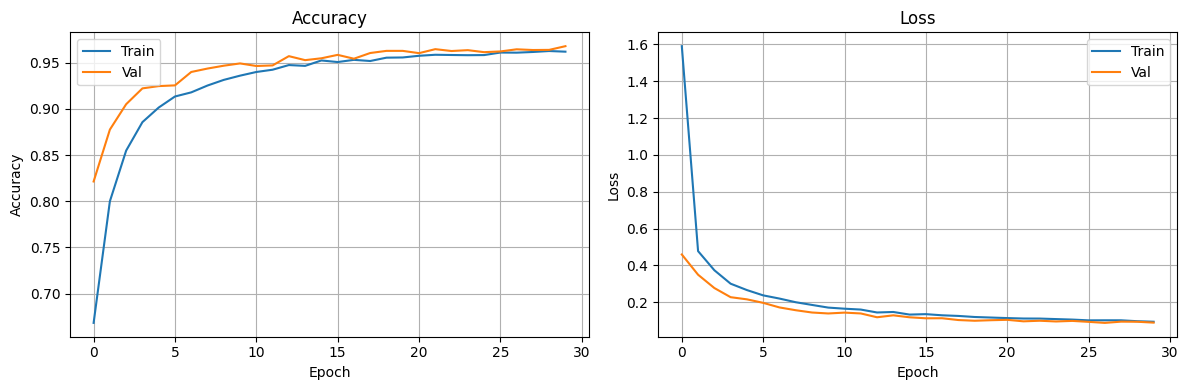

✓ Training plot saved


In [ ]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Val')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid()

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.savefig('training_history.png', dpi=100, bbox_inches='tight')
plt.show()

print('✓ Training plot saved')

In [ ]:
# Convert to TFLite INT8
print('Converting to TFLite INT8...')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Representative dataset for quantization
def representative_data():
    for i in range(min(200, len(X_train))):
        yield [X_train[i:i+1].astype(np.float32)]

converter.representative_dataset = representative_data
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

# Save TFLite model
with open('model_esp32.tflite', 'wb') as f:
    f.write(tflite_model)

model_size_kb = len(tflite_model) / 1024
print(f'\n✓ TFLite Model saved')
print(f'  Size: {model_size_kb:.1f} KB')
print(f'  Fits in ESP32: {"YES ✓" if model_size_kb < 100 else "NO - too large"}')

Converting to TFLite INT8...
Saved artifact at '/tmp/tmpg1q3c7ix'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 511), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  133944725085584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133944725088656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133944725090192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133944725089040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133944725088848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133944725090384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133944725091152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133944725089616: TensorSpec(shape=(), dtype=tf.resource, name=None)

✓ TFLite Model saved
  Size: 40.4 KB
  Fits in ESP32: YES ✓


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [ ]:
# Generate Arduino C header
print('Generating Arduino C header...')

with open('model_esp32.tflite', 'rb') as f:
    model_data = f.read()

header = '// Auto-generated TFLite model header\n'
header += f'// Model size: {len(model_data):,} bytes\n'
header += f'// Features: {X_train.shape[1]}\n'
header += f'// Accuracy: {test_acc*100:.2f}%\n'
header += f'// F1-Score: {f1:.4f}\n'
header += '\n'
header += '#pragma once\n'
header += '#include <stdint.h>\n'
header += '\n'
header += f'const unsigned int model_len = {len(model_data)};\n'
header += 'alignas(8) const unsigned char model[] = {\n'

hex_vals = [f'0x{b:02x}' for b in model_data]
for i in range(0, len(hex_vals), 16):
    batch = hex_vals[i:i+16]
    header += '  ' + ', '.join(batch) + ',\n'

header = header[:-2] + '\n};'

with open('model.h', 'w') as f:
    f.write(header)

print('✓ Generated: model.h')

Generating Arduino C header...
✓ Generated: model.h


In [ ]:
# Generate Arduino sketch
print('Generating Arduino sketch...')

sketch = '''#include <Wire.h>
#include "tensorflow/lite/micro/all_ops_resolver.h"
#include "tensorflow/lite/micro/micro_error_reporter.h"
#include "tensorflow/lite/micro/micro_interpreter.h"
#include "tensorflow/lite/schema/schema_generated.h"
#include "tensorflow/lite/version.h"
#include "model.h"

namespace {
  tflite::ErrorReporter* error_reporter = nullptr;
  const tflite::Model* model = nullptr;
  tflite::MicroInterpreter* interpreter = nullptr;
  TfLiteTensor* input = nullptr;
  TfLiteTensor* output = nullptr;
  constexpr int kTensorArenaSize = 8 * 1024;
  uint8_t tensor_arena[kTensorArenaSize];
}

void setup() {
  Serial.begin(115200);
  delay(1000);

  Serial.println("\\n=== ESP32 TinyML Inference ===");

  static tflite::MicroErrorReporter micro_error_reporter;
  error_reporter = &micro_error_reporter;

  model = tflite::GetModel(model);

  static tflite::AllOpsResolver resolver;
  static tflite::MicroInterpreter static_interpreter(
    model, resolver, tensor_arena, kTensorArenaSize, error_reporter);
  interpreter = &static_interpreter;

  if (interpreter->AllocateTensors() != kTfLiteOk) {
    error_reporter->Report("AllocateTensors failed");
    return;
  }

  input = interpreter->input(0);
  output = interpreter->output(0);

  Serial.println("✓ Model loaded!");
  Serial.println("Ready for inference...");
}

void loop() {
  // Example: Run inference with test data
  // Replace with your actual sensor data

  // Input your features here
  // for (int i = 0; i < input->dims->data[1]; i++) {
  //   input->data.f[i] = your_feature[i];
  // }

  if (interpreter->Invoke() != kTfLiteOk) {
    error_reporter->Report("Invoke failed");
    return;
  }

  float output_val = output->data.f[0];
  int prediction = (output_val > 0.5) ? 1 : 0;

  Serial.print("Prediction: ");
  Serial.print(prediction);
  Serial.print(" (confidence: ");
  Serial.print(output_val);
  Serial.println(")");

  delay(1000);
}
'''

with open('esp32_inference.ino', 'w') as f:
    f.write(sketch)

print('✓ Generated: esp32_inference.ino')

Generating Arduino sketch...
✓ Generated: esp32_inference.ino


In [ ]:
# Summary
print('\n' + '='*60)
print('🎉 MODEL TRAINING & CONVERSION COMPLETE!')
print('='*60)
print(f'\n📊 Performance:')
print(f'  Accuracy: {test_acc*100:.2f}%')
print(f'  F1-Score: {f1:.4f}')
print(f'\n💾 Model Files:')
print(f'  - model_esp32.tflite ({model_size_kb:.1f} KB)')
print(f'  - model.h (C header)')
print(f'  - esp32_inference.ino (Arduino sketch)')
print(f'\n✅ ESP32 Compatibility:')
print(f'  Model fits: YES ✓')
print(f'  Ready to deploy: YES ✓')
print(f'\n🚀 Next Steps:')
print(f'  1. Download all 3 files from Colab')
print(f'  2. Open Arduino IDE')
print(f'  3. Create sketch folder')
print(f'  4. Add model.h and esp32_inference.ino')
print(f'  5. Install TensorFlow Lite Micro library')
print(f'  6. Select ESP32 board')
print(f'  7. Upload to ESP32')
print(f'  8. DONE! 🎉')


🎉 MODEL TRAINING & CONVERSION COMPLETE!

📊 Performance:
  Accuracy: 97.33%
  F1-Score: 0.9747

💾 Model Files:
  - model_esp32.tflite (40.4 KB)
  - model.h (C header)
  - esp32_inference.ino (Arduino sketch)

✅ ESP32 Compatibility:
  Model fits: YES ✓
  Ready to deploy: YES ✓

🚀 Next Steps:
  1. Download all 3 files from Colab
  2. Open Arduino IDE
  3. Create sketch folder
  4. Add model.h and esp32_inference.ino
  5. Install TensorFlow Lite Micro library
  6. Select ESP32 board
  7. Upload to ESP32
  8. DONE! 🎉
